# Floquet memory circuit, step by step

This builds `memory_circuit` (src/two_ancillas/floquet.py) one piece at a time and draws each piece:
lattice → one parity check → reset → the 6 steps → detectors → observable → readout → noise → decoding.
For the Makefile parameters and full LER sweeps, see `memory_experiment.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# the repo root, whether the kernel starts there or in notebooks/two_ancillas/
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "two_ancillas").is_dir())
sys.path.insert(0, str(ROOT / "src" / "two_ancillas"))

import matplotlib.pyplot as plt
import numpy as np
import stim
from IPython.display import SVG, display

from floquet import edge_list, hex_centers, memory_circuit, parity_check, qubit_kinds, qubits, round_circuit
from memory import count_logical_errors
from noise import NOISE_MODELS, add_noise
from plots import COLORS, layout_figure, round_svg

DRAW = 1       # distance for the drawings: 12 data qubits, 48 qubits in all
D = 3          # distance for sampling and decoding
NOISE, ETA, P = "spin", 10.0, 1e-3
SHOTS = 20_000

## 1. The lattice

Hexagonal plaquettes on a torus, 3-coloured. Data qubits sit on the corners; every edge carries a spin-ancilla
pair: a syndrome ancilla S next to its first data qubit and a reference R next to the second.
An edge of colour c joins two colour-c plaquettes.

{'data': 12, 'main': 18, 'reff': 18} | 18 edges


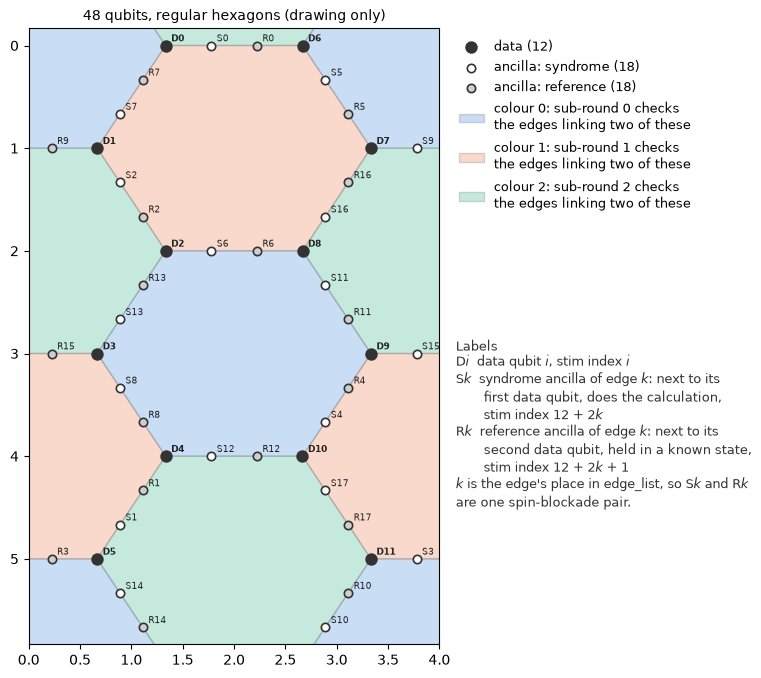

In [2]:
layout_figure(DRAW, hex_view=True, numbers=True);
kinds = list(qubit_kinds(DRAW).values())
print({k: kinds.count(k) for k in ("data", "main", "reff")}, "|", len(edge_list(DRAW)), "edges")

## 2. One parity check on one edge

`parity_check` measures X⊗X or Z⊗Z of two data qubits (d0, d1) through the ancilla pair: syndrome picks up
P_d0, SWAPs to the dot next to d1, picks up P_d1, and the pair is read out together as one Z⊗Z (spin blockade).
Here on 4 qubits: d0 = 0, d1 = 1, S = 2, R = 3.

ZZ check


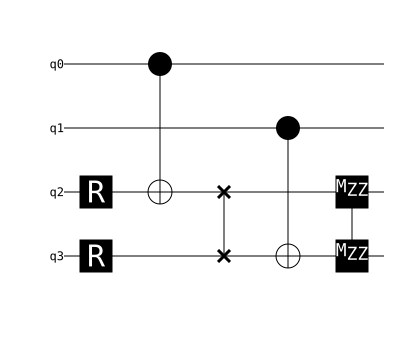

XX check


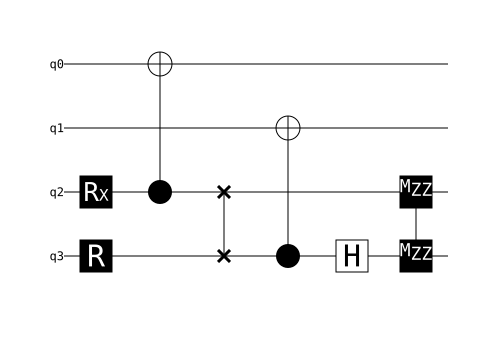

In [3]:
def one_check(pauli):
    c = stim.Circuit()
    for layer in parity_check(pauli, 0, 1, 2, 3):
        for name, targets in layer:
            c.append(name, targets)
        c.append("TICK")
    return c

for pauli in "ZX":
    print(f"{pauli}{pauli} check")
    display(one_check(pauli).diagram("timeline-svg"))

Sanity check: prepare the data qubits in eigenstates of the measured parity and see the readout match.
|01⟩ has ZZ = −1 and |+−⟩ has XX = −1, so both should read 1 every shot; |00⟩ and |++⟩ should read 0.

In [4]:
prep = {"Z": {"|00>": "", "|01>": "X 1"}, "X": {"|++>": "H 0 1", "|+->": "X 1\nH 0 1"}}
for pauli, states in prep.items():
    for label, ops in states.items():
        shots = (stim.Circuit(ops) + one_check(pauli)).compile_sampler().sample(1000)
        print(f"{pauli}{pauli} on {label}: outcomes {set(map(int, shots[:, 0]))}")

ZZ on |00>: outcomes {0}
ZZ on |01>: outcomes {1}
XX on |++>: outcomes {0}
XX on |+->: outcomes {1}


## 3. Reset

Every data qubit to |0⟩. All Z plaquettes now have a known value (+1); X plaquettes are random.

In [5]:
c = memory_circuit(DRAW, 1)
print(c[:2])  # the reset and its TICK; each step then declares its qubits' coordinates

R 0 1 2 3 4 5 6 7 8 9 10 11
TICK


## 4. The 6 steps of one period

Schedule **bX rZ gX bZ rX gZ**: step r checks every edge of colour r % 3, in X on even steps and Z on odd ones.
Each qubit is in exactly one check per step. Every check runs its layers in lockstep, so one step is 5 (Z) or 6 (X) TICKs.

step 0: XX on colour 0 edges, 6 ticks


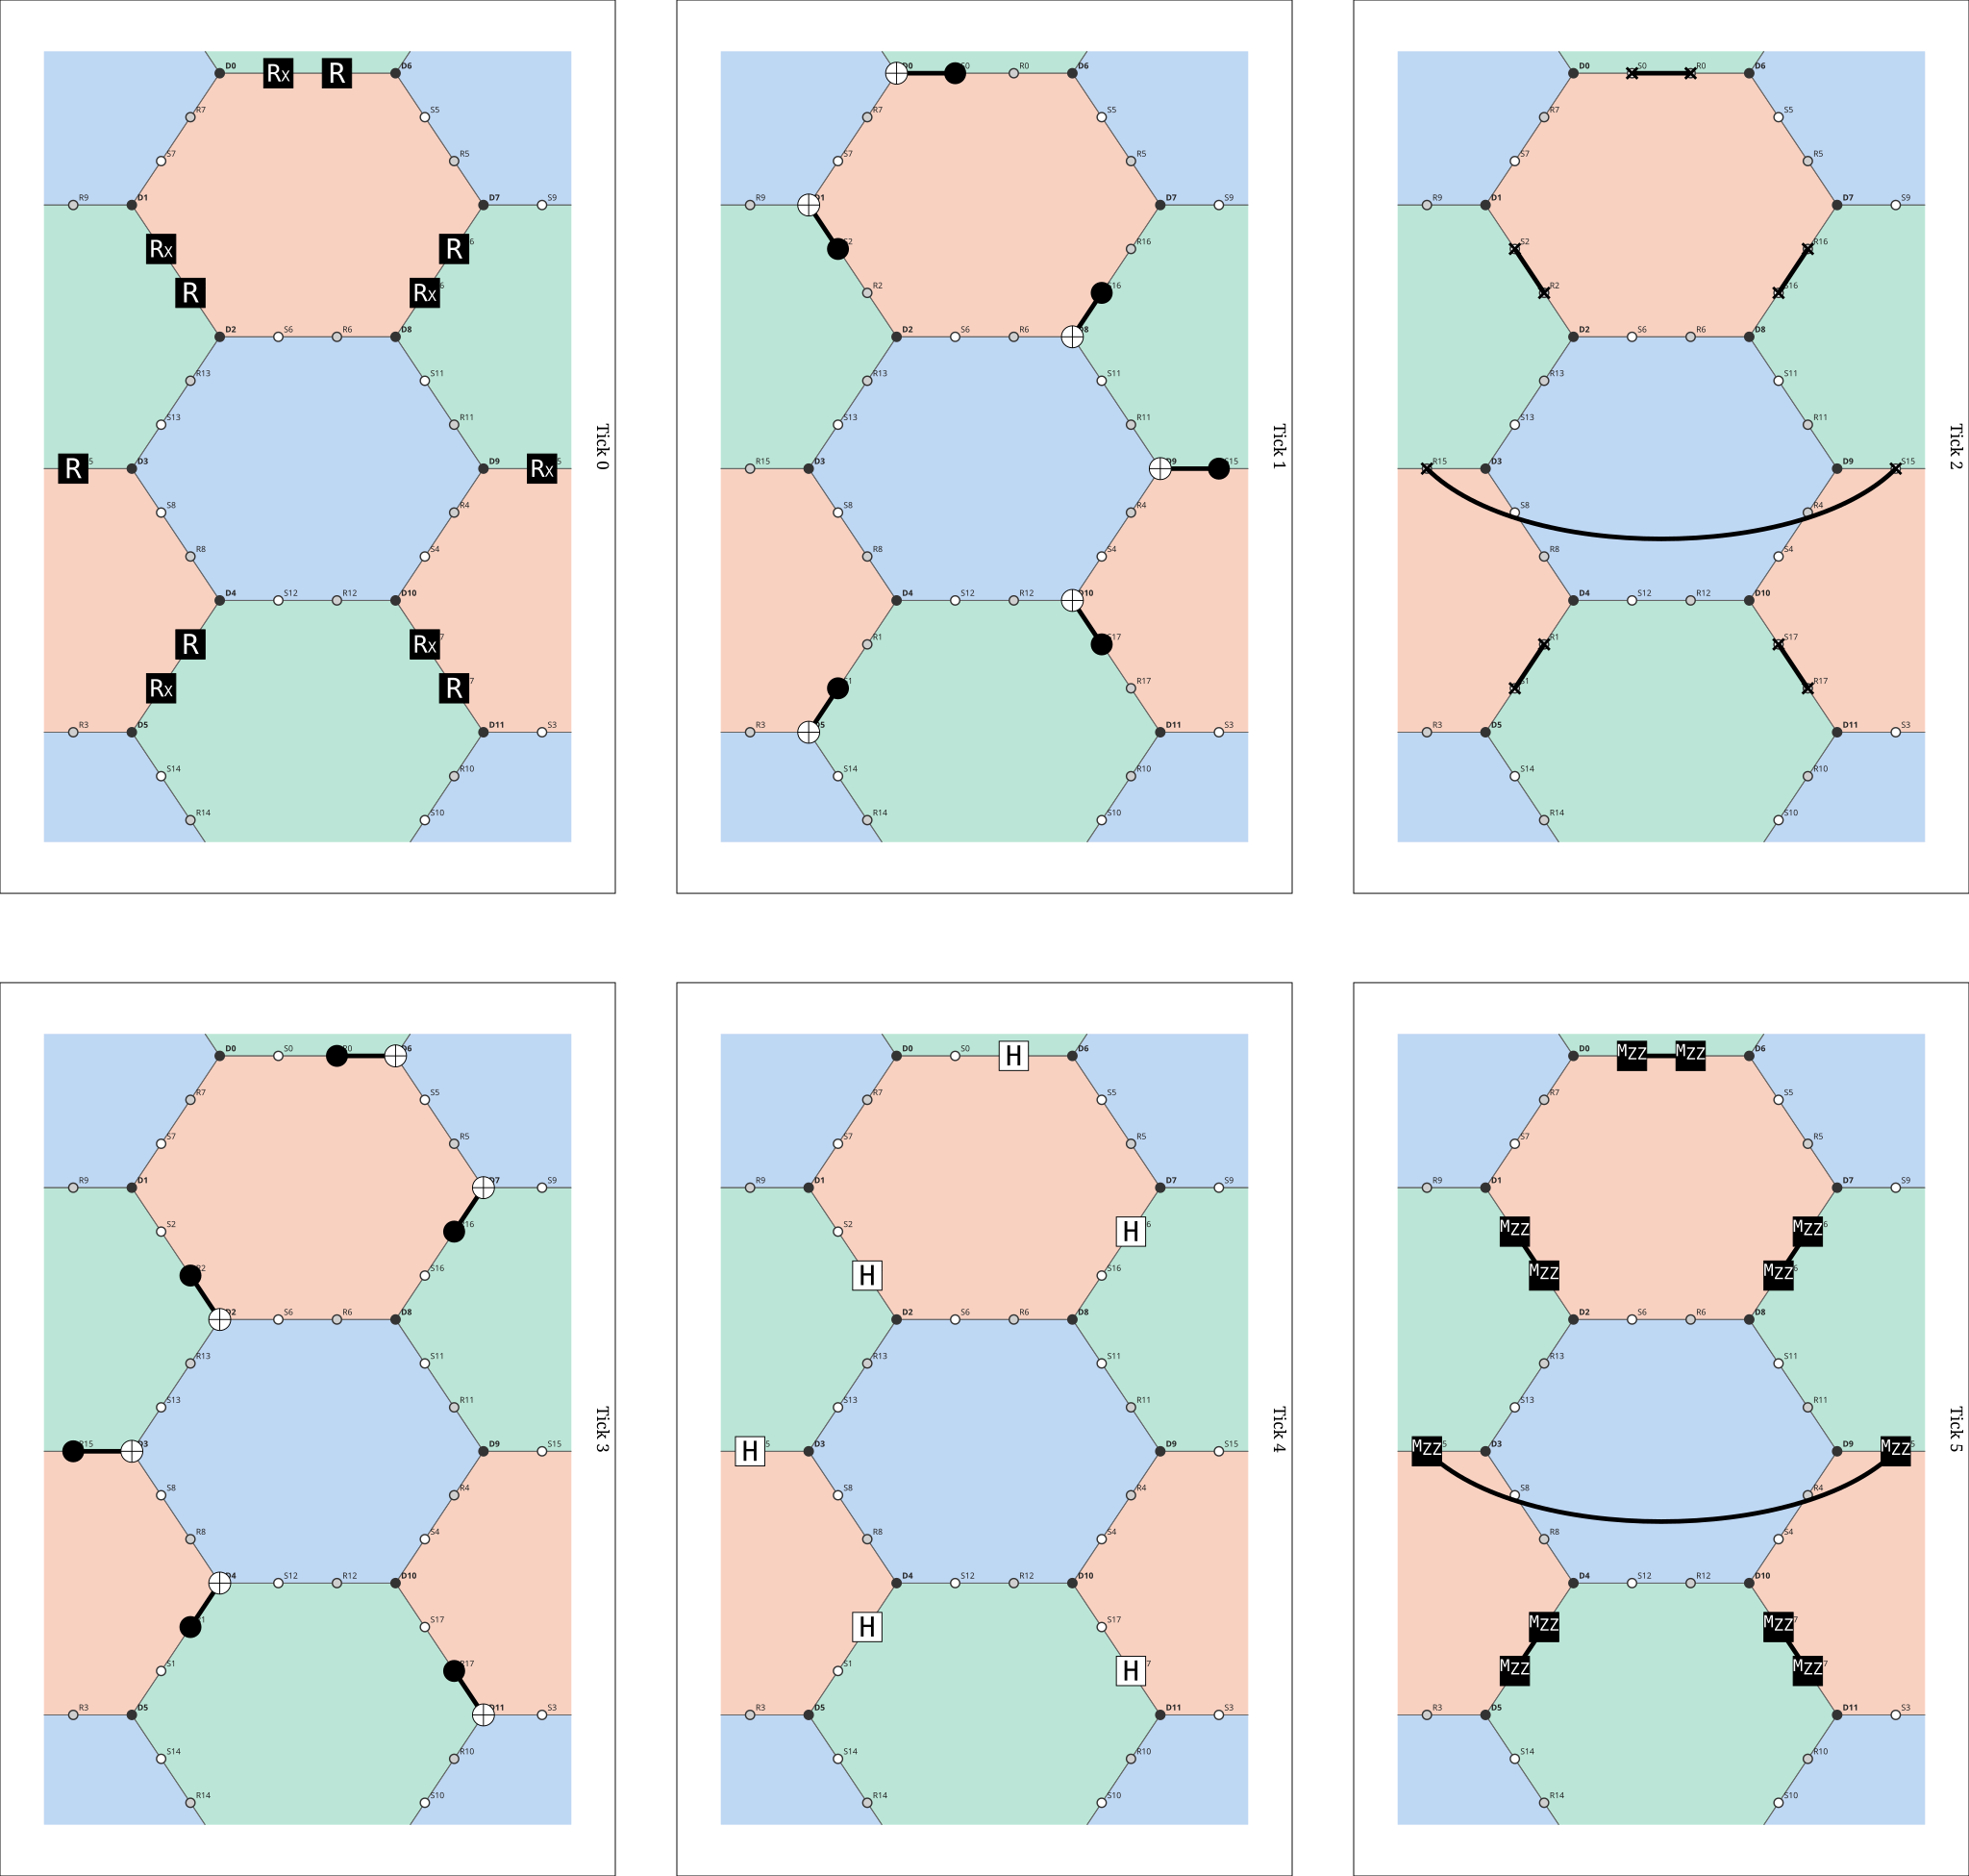

step 1: ZZ on colour 1 edges, 5 ticks


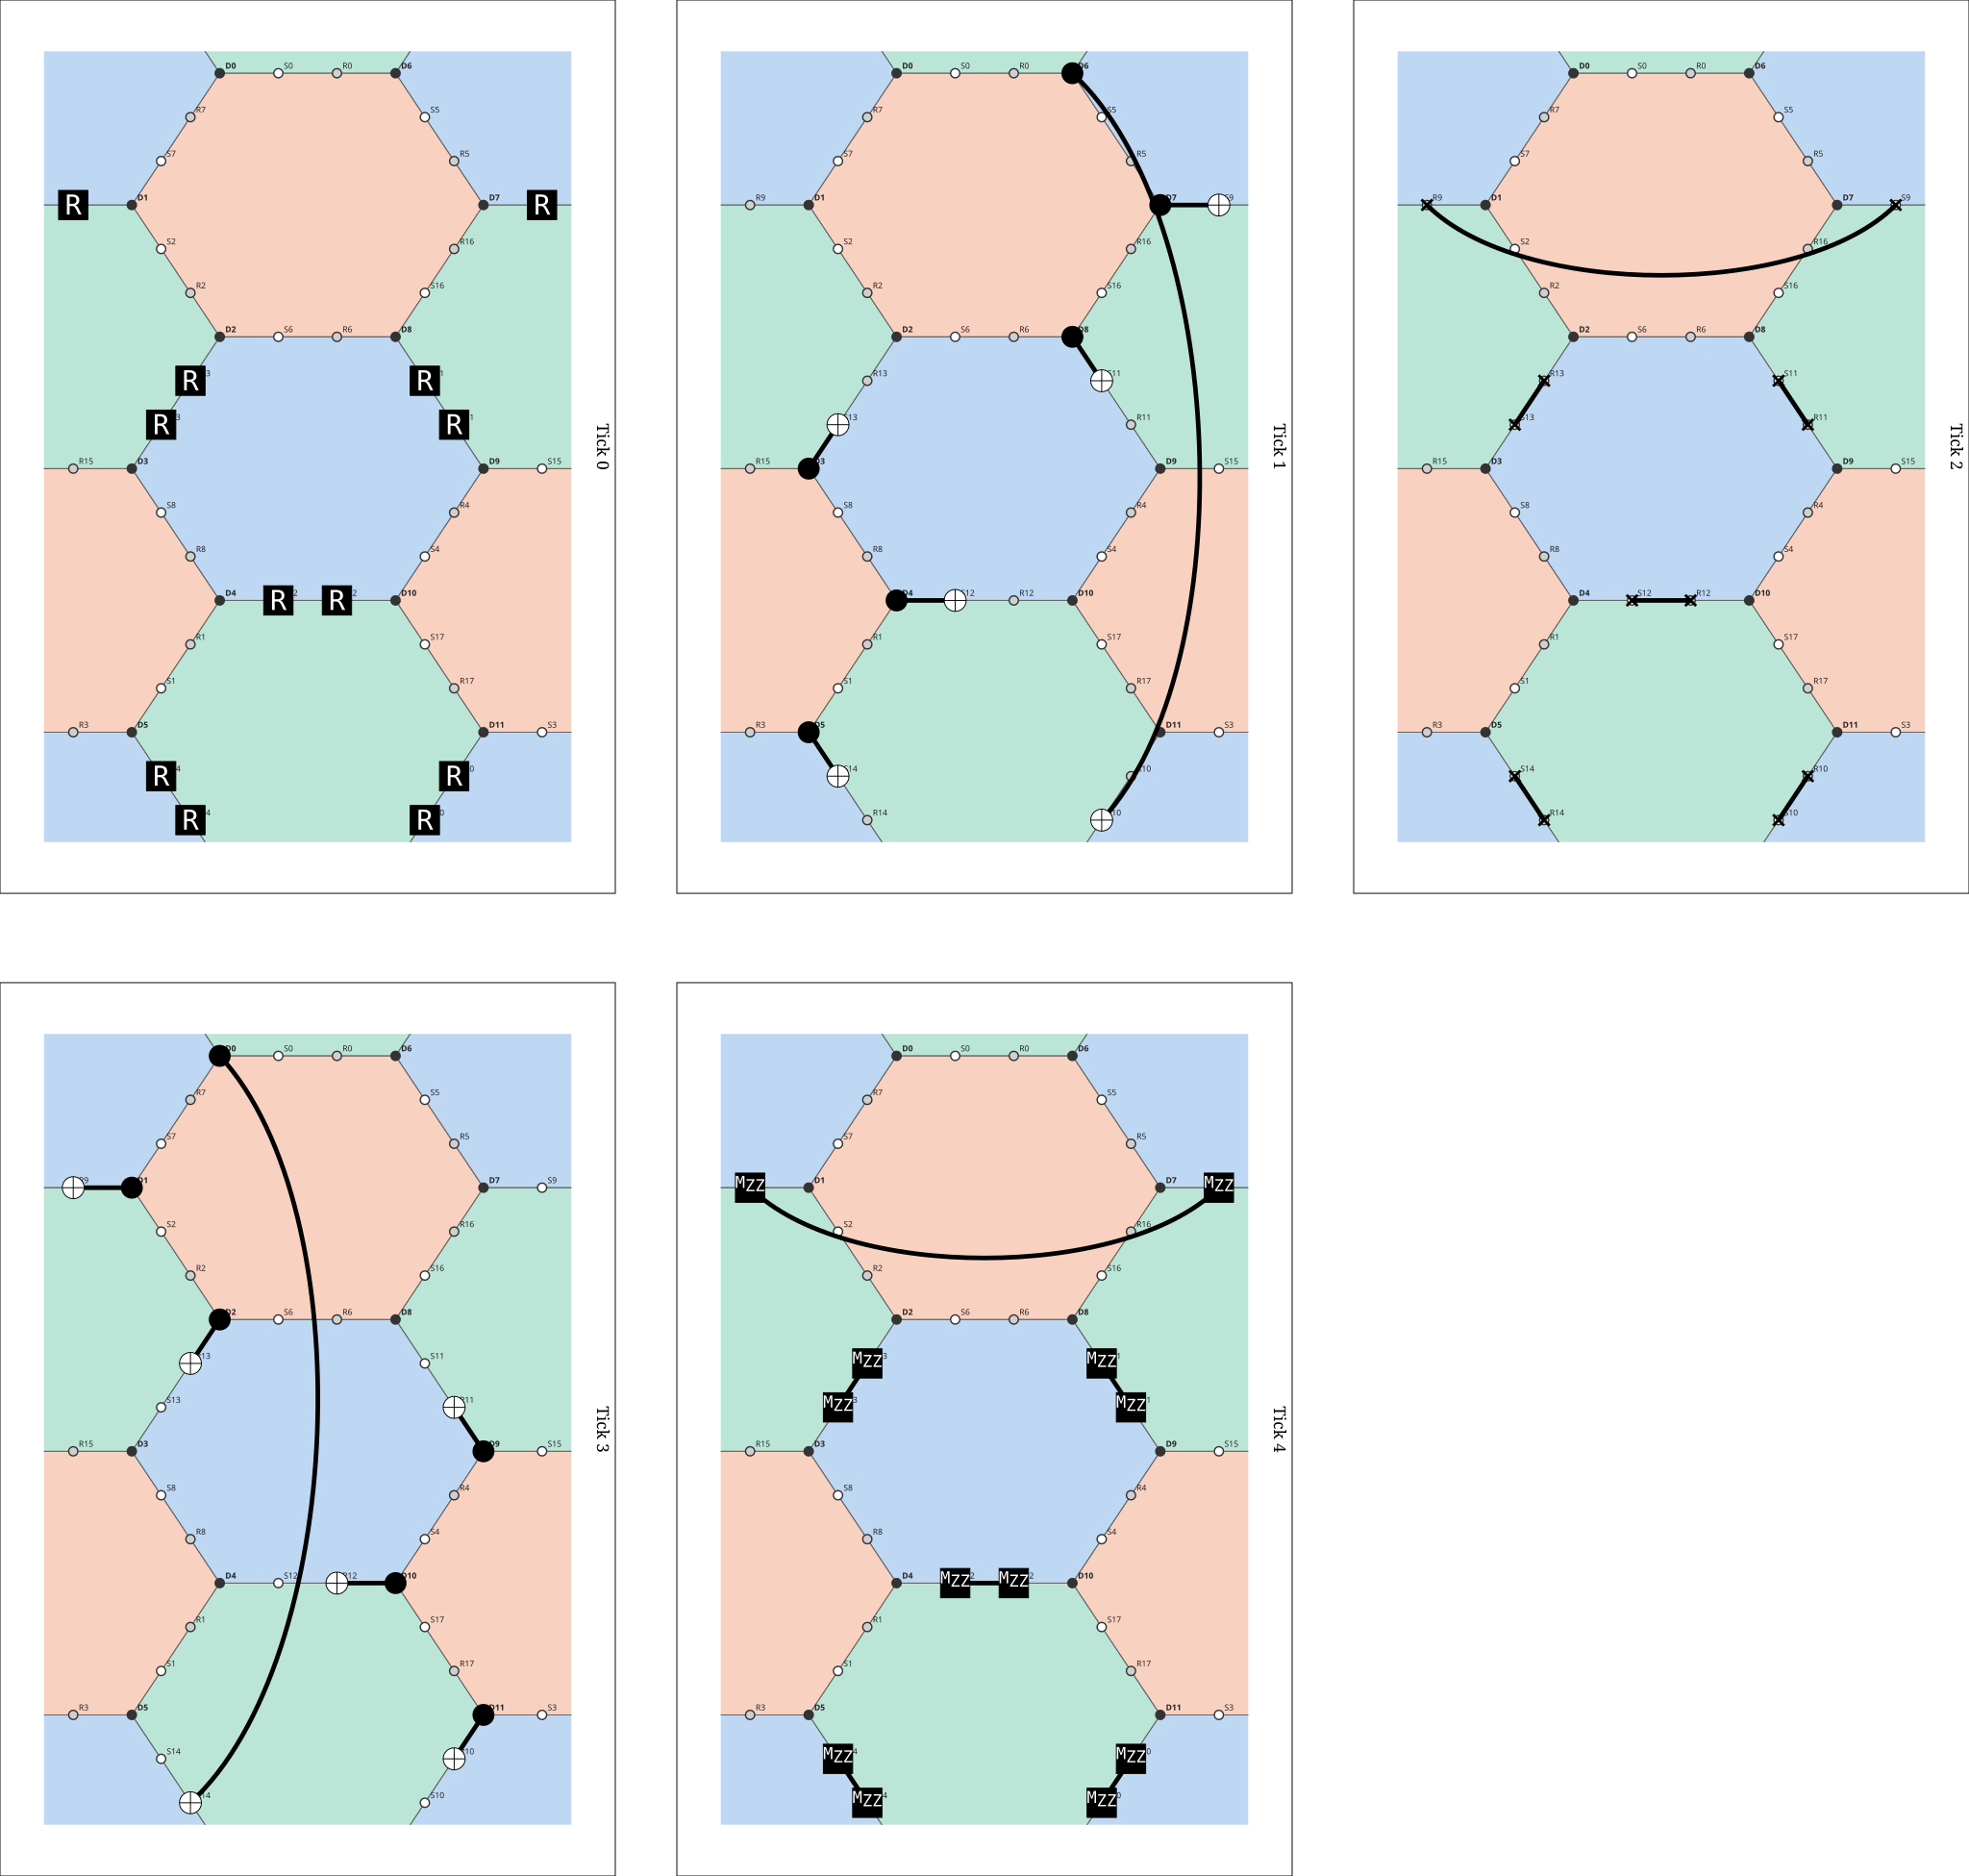

step 2: XX on colour 2 edges, 6 ticks


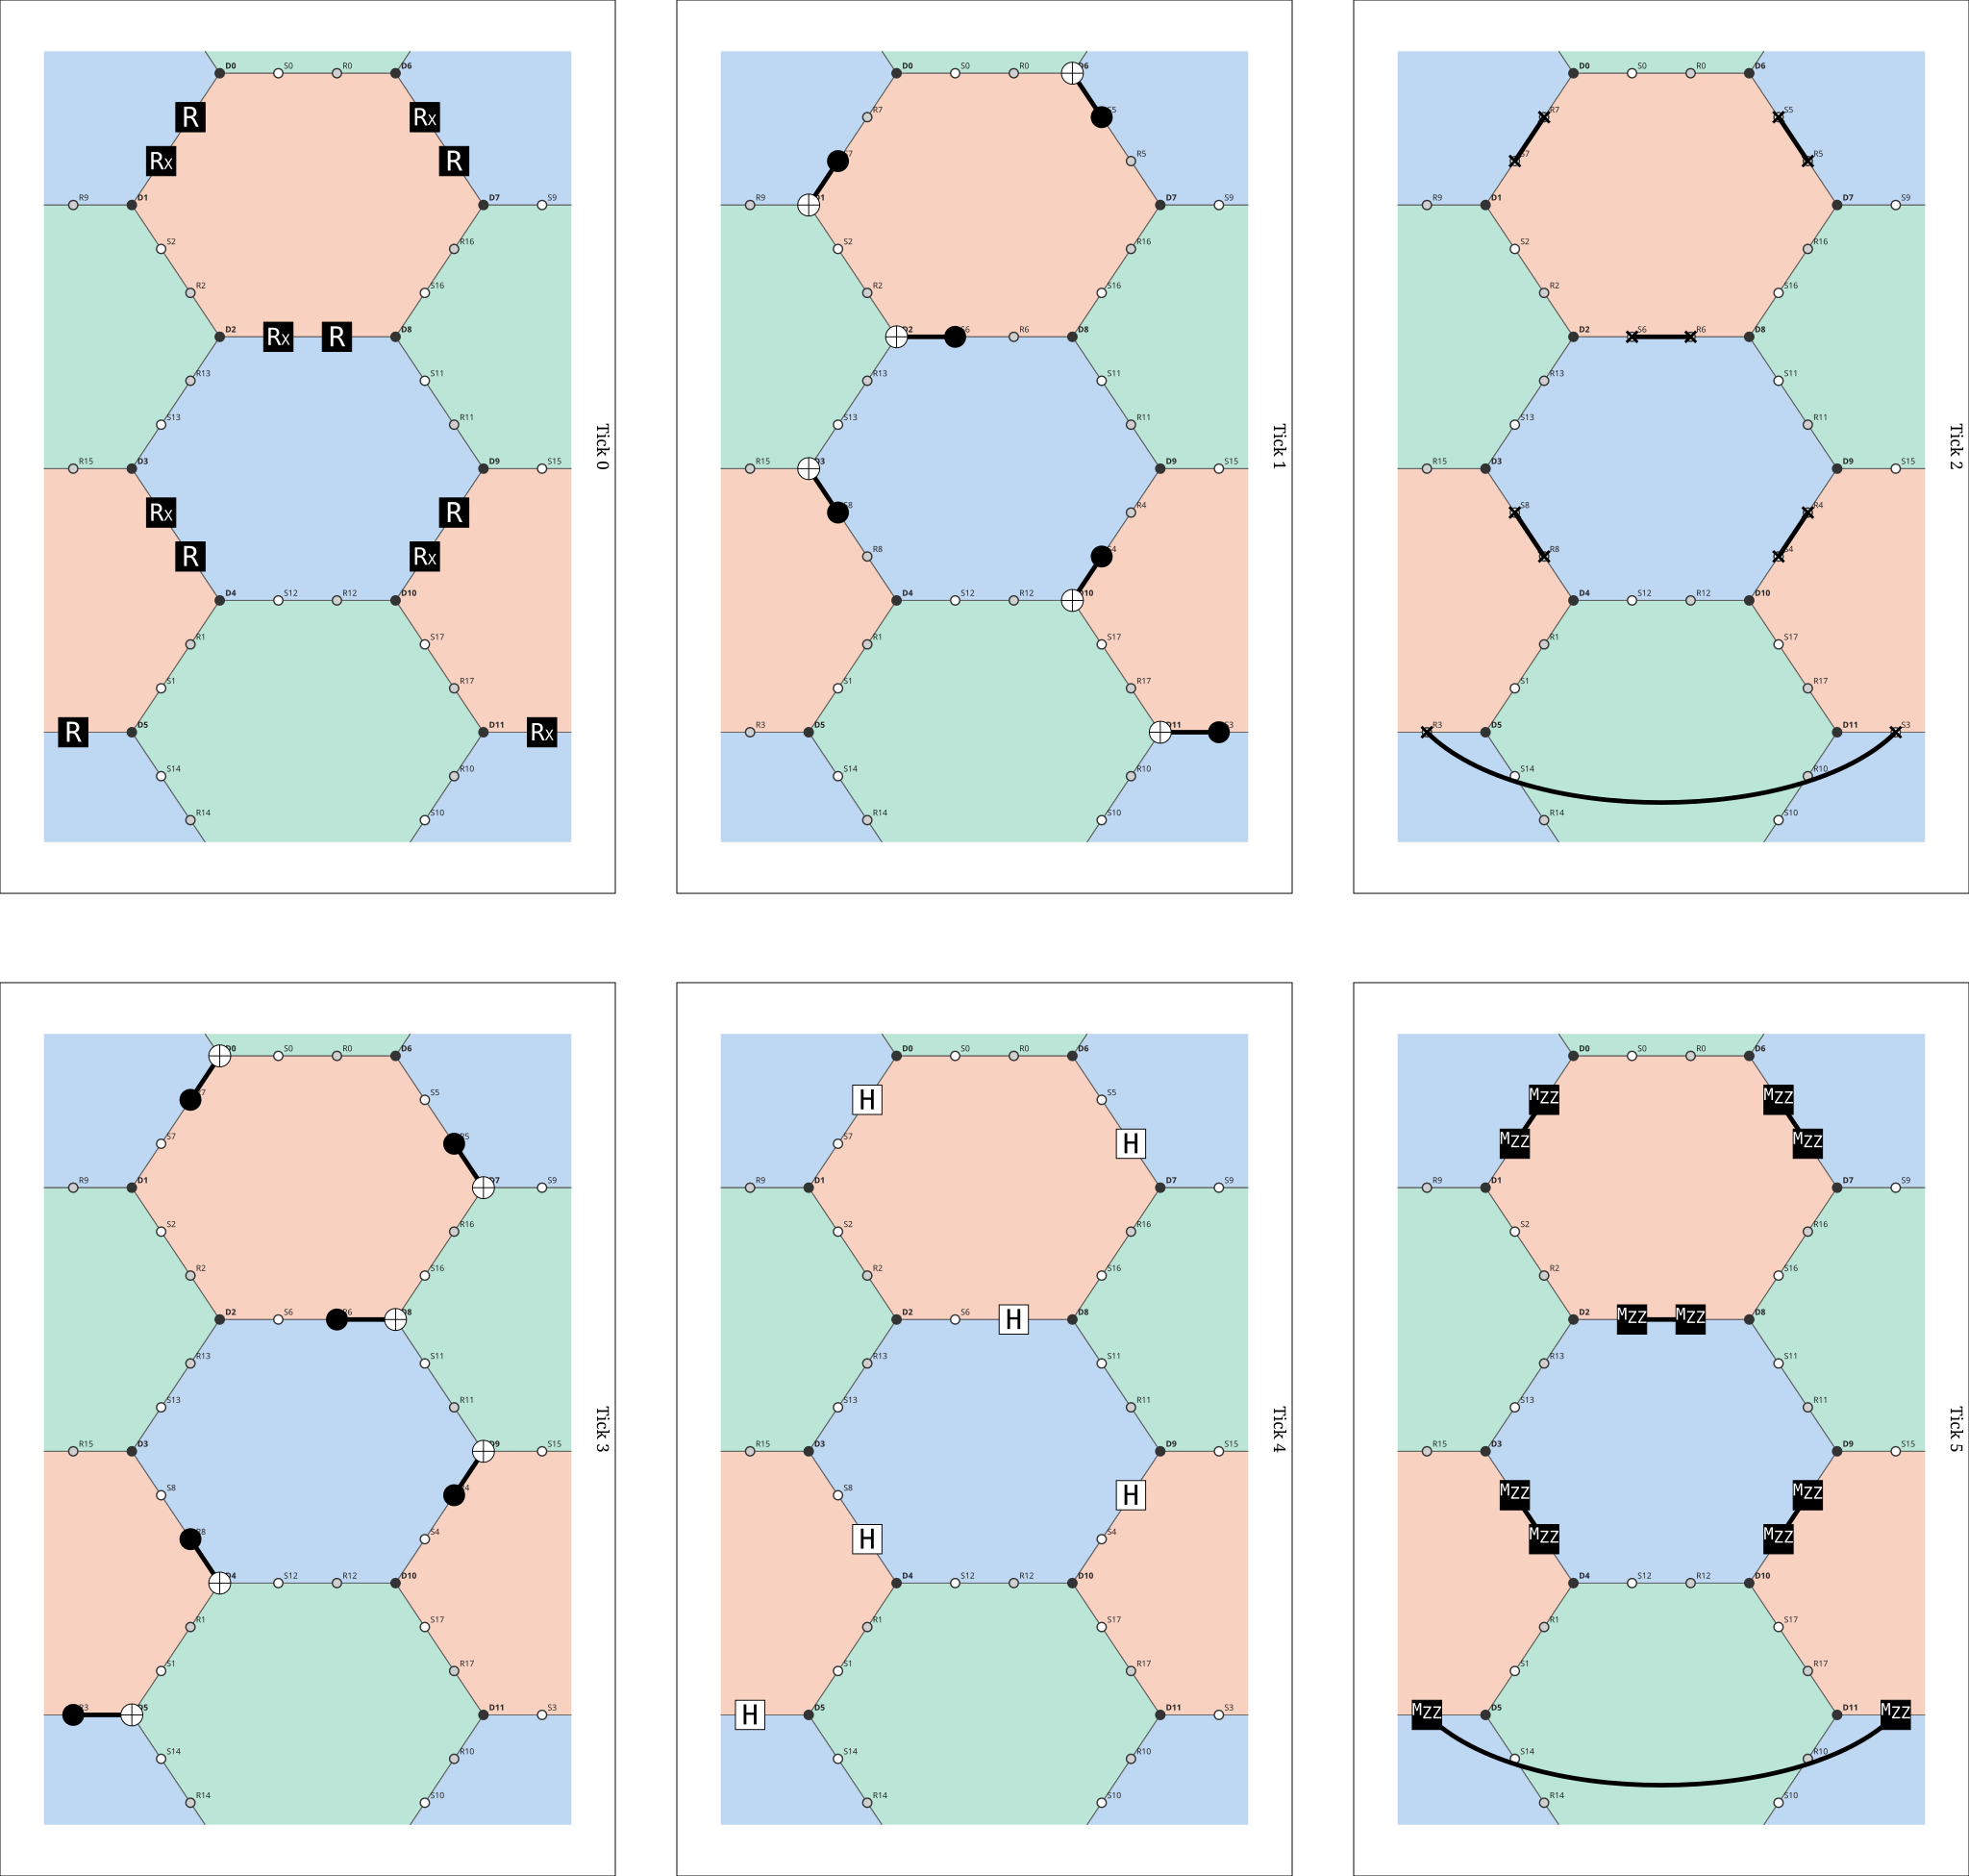

step 3: ZZ on colour 0 edges, 5 ticks


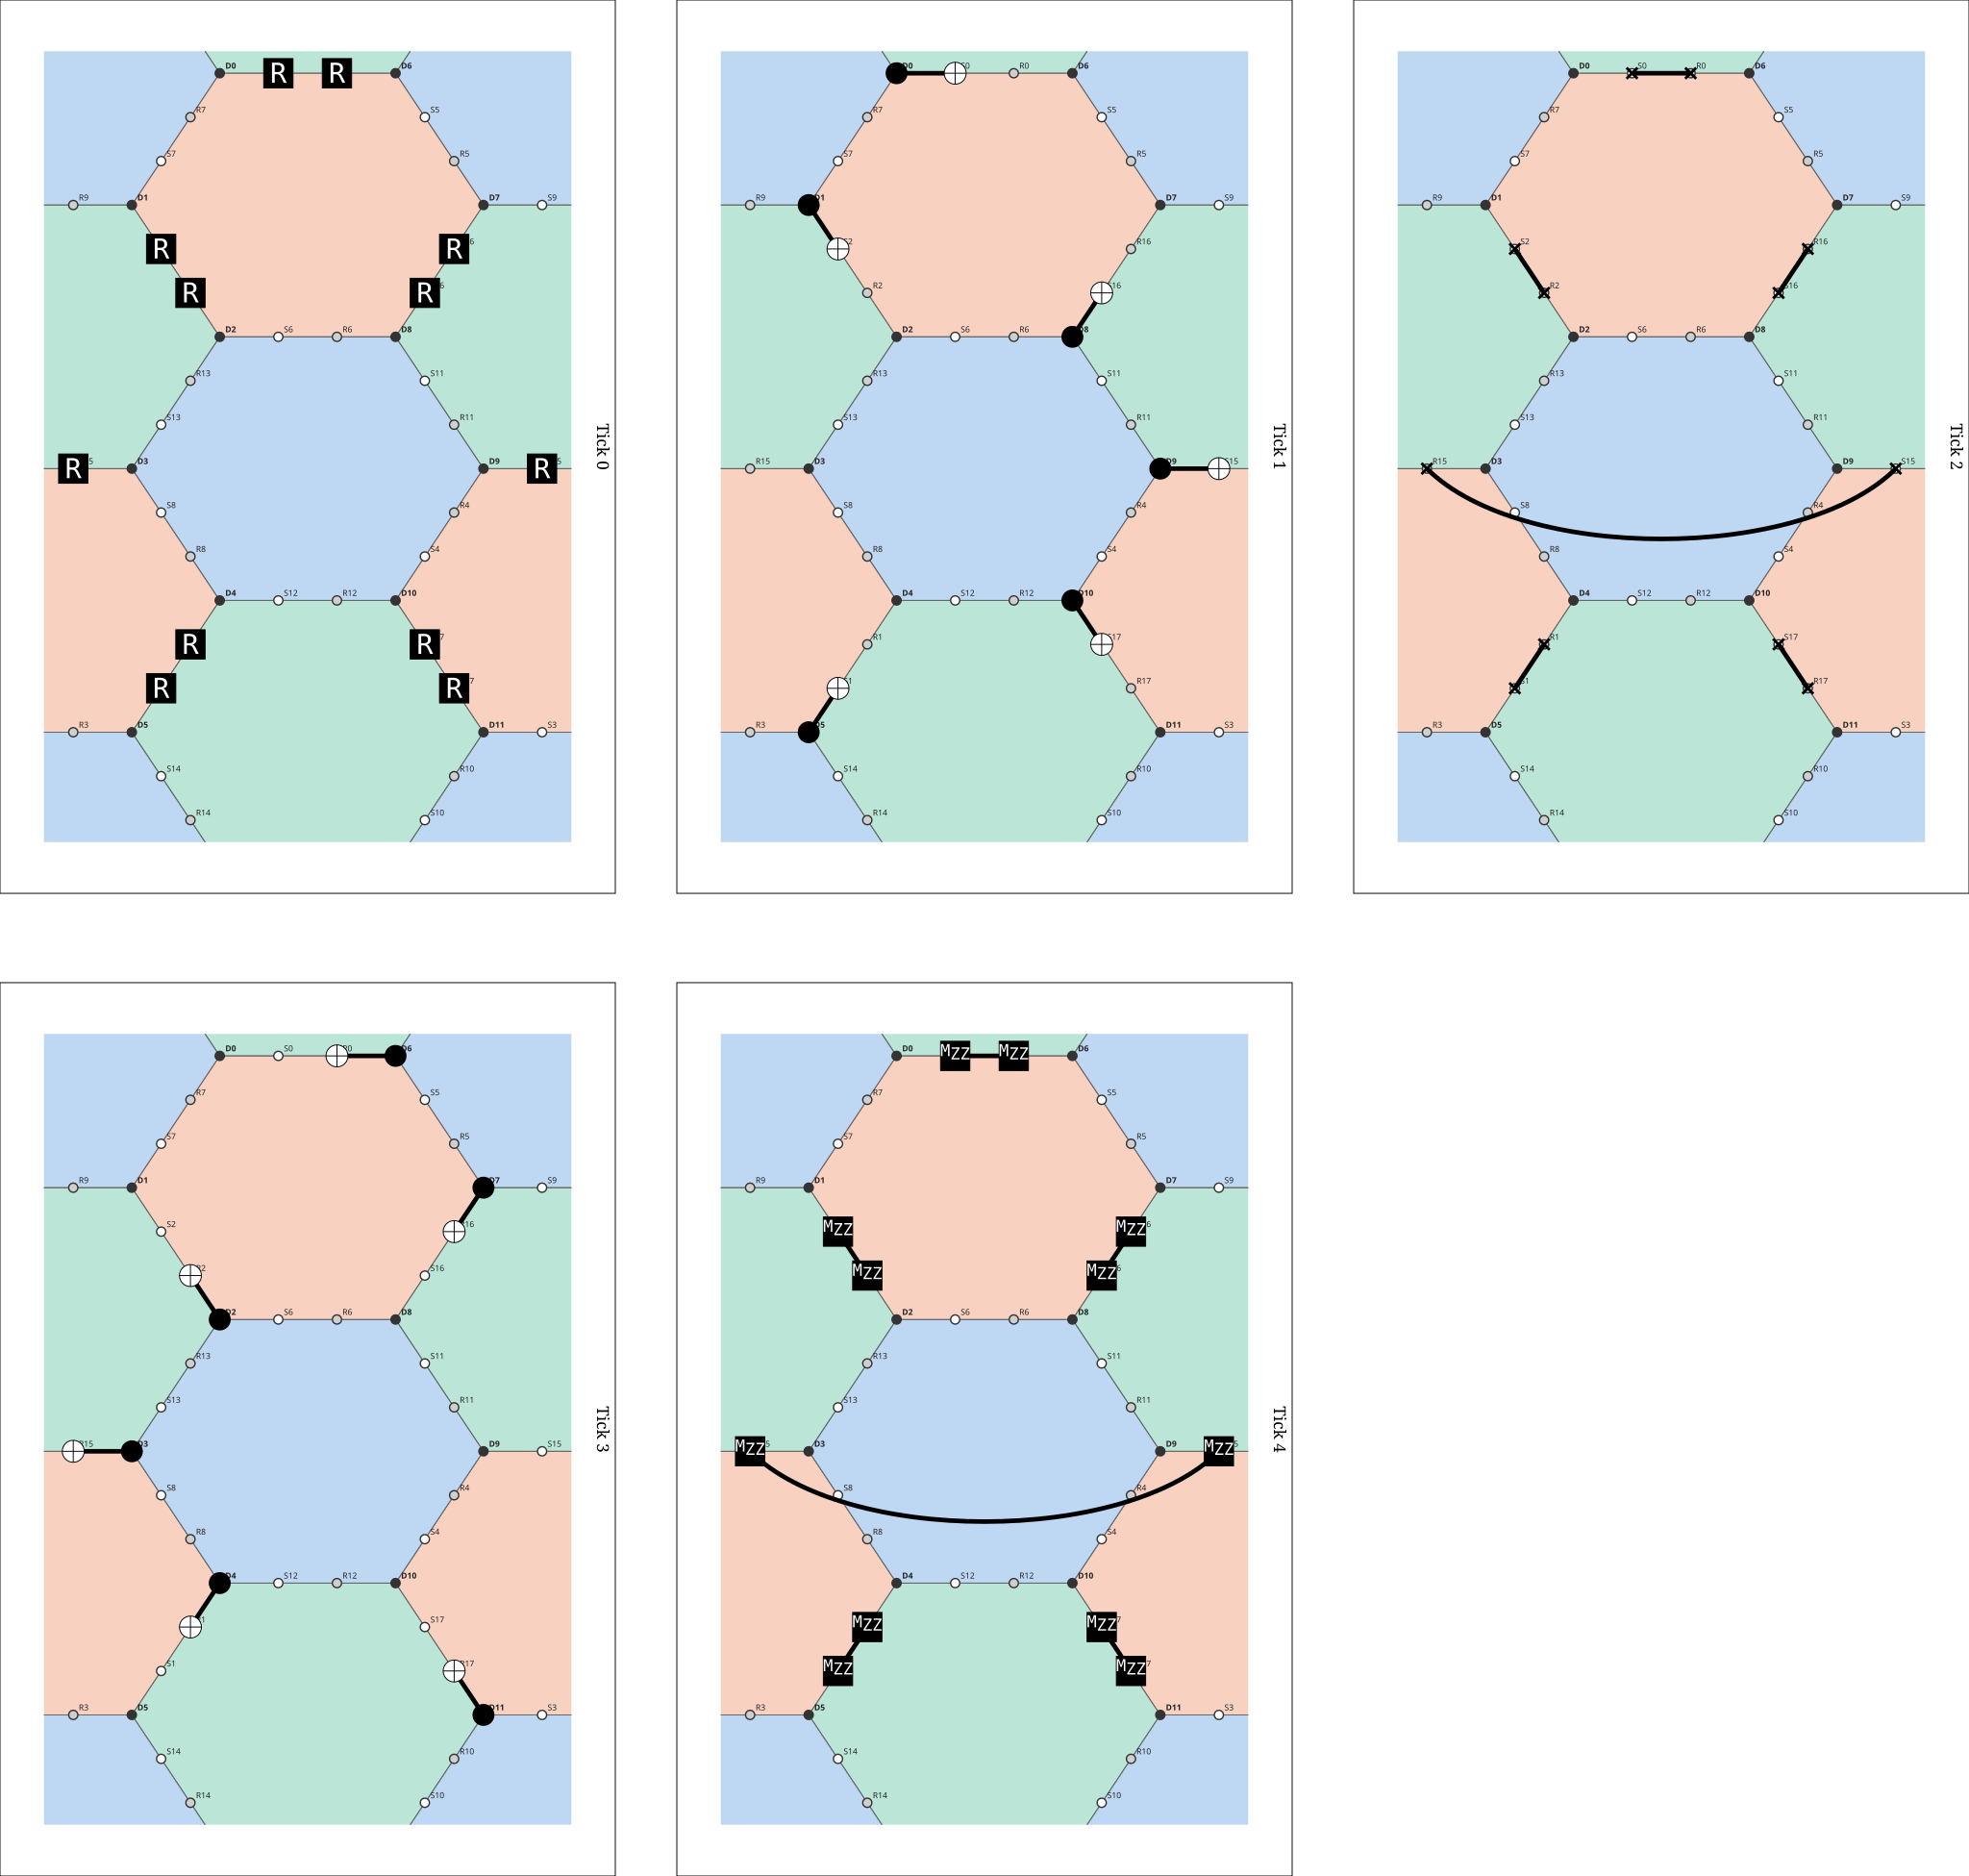

step 4: XX on colour 1 edges, 6 ticks


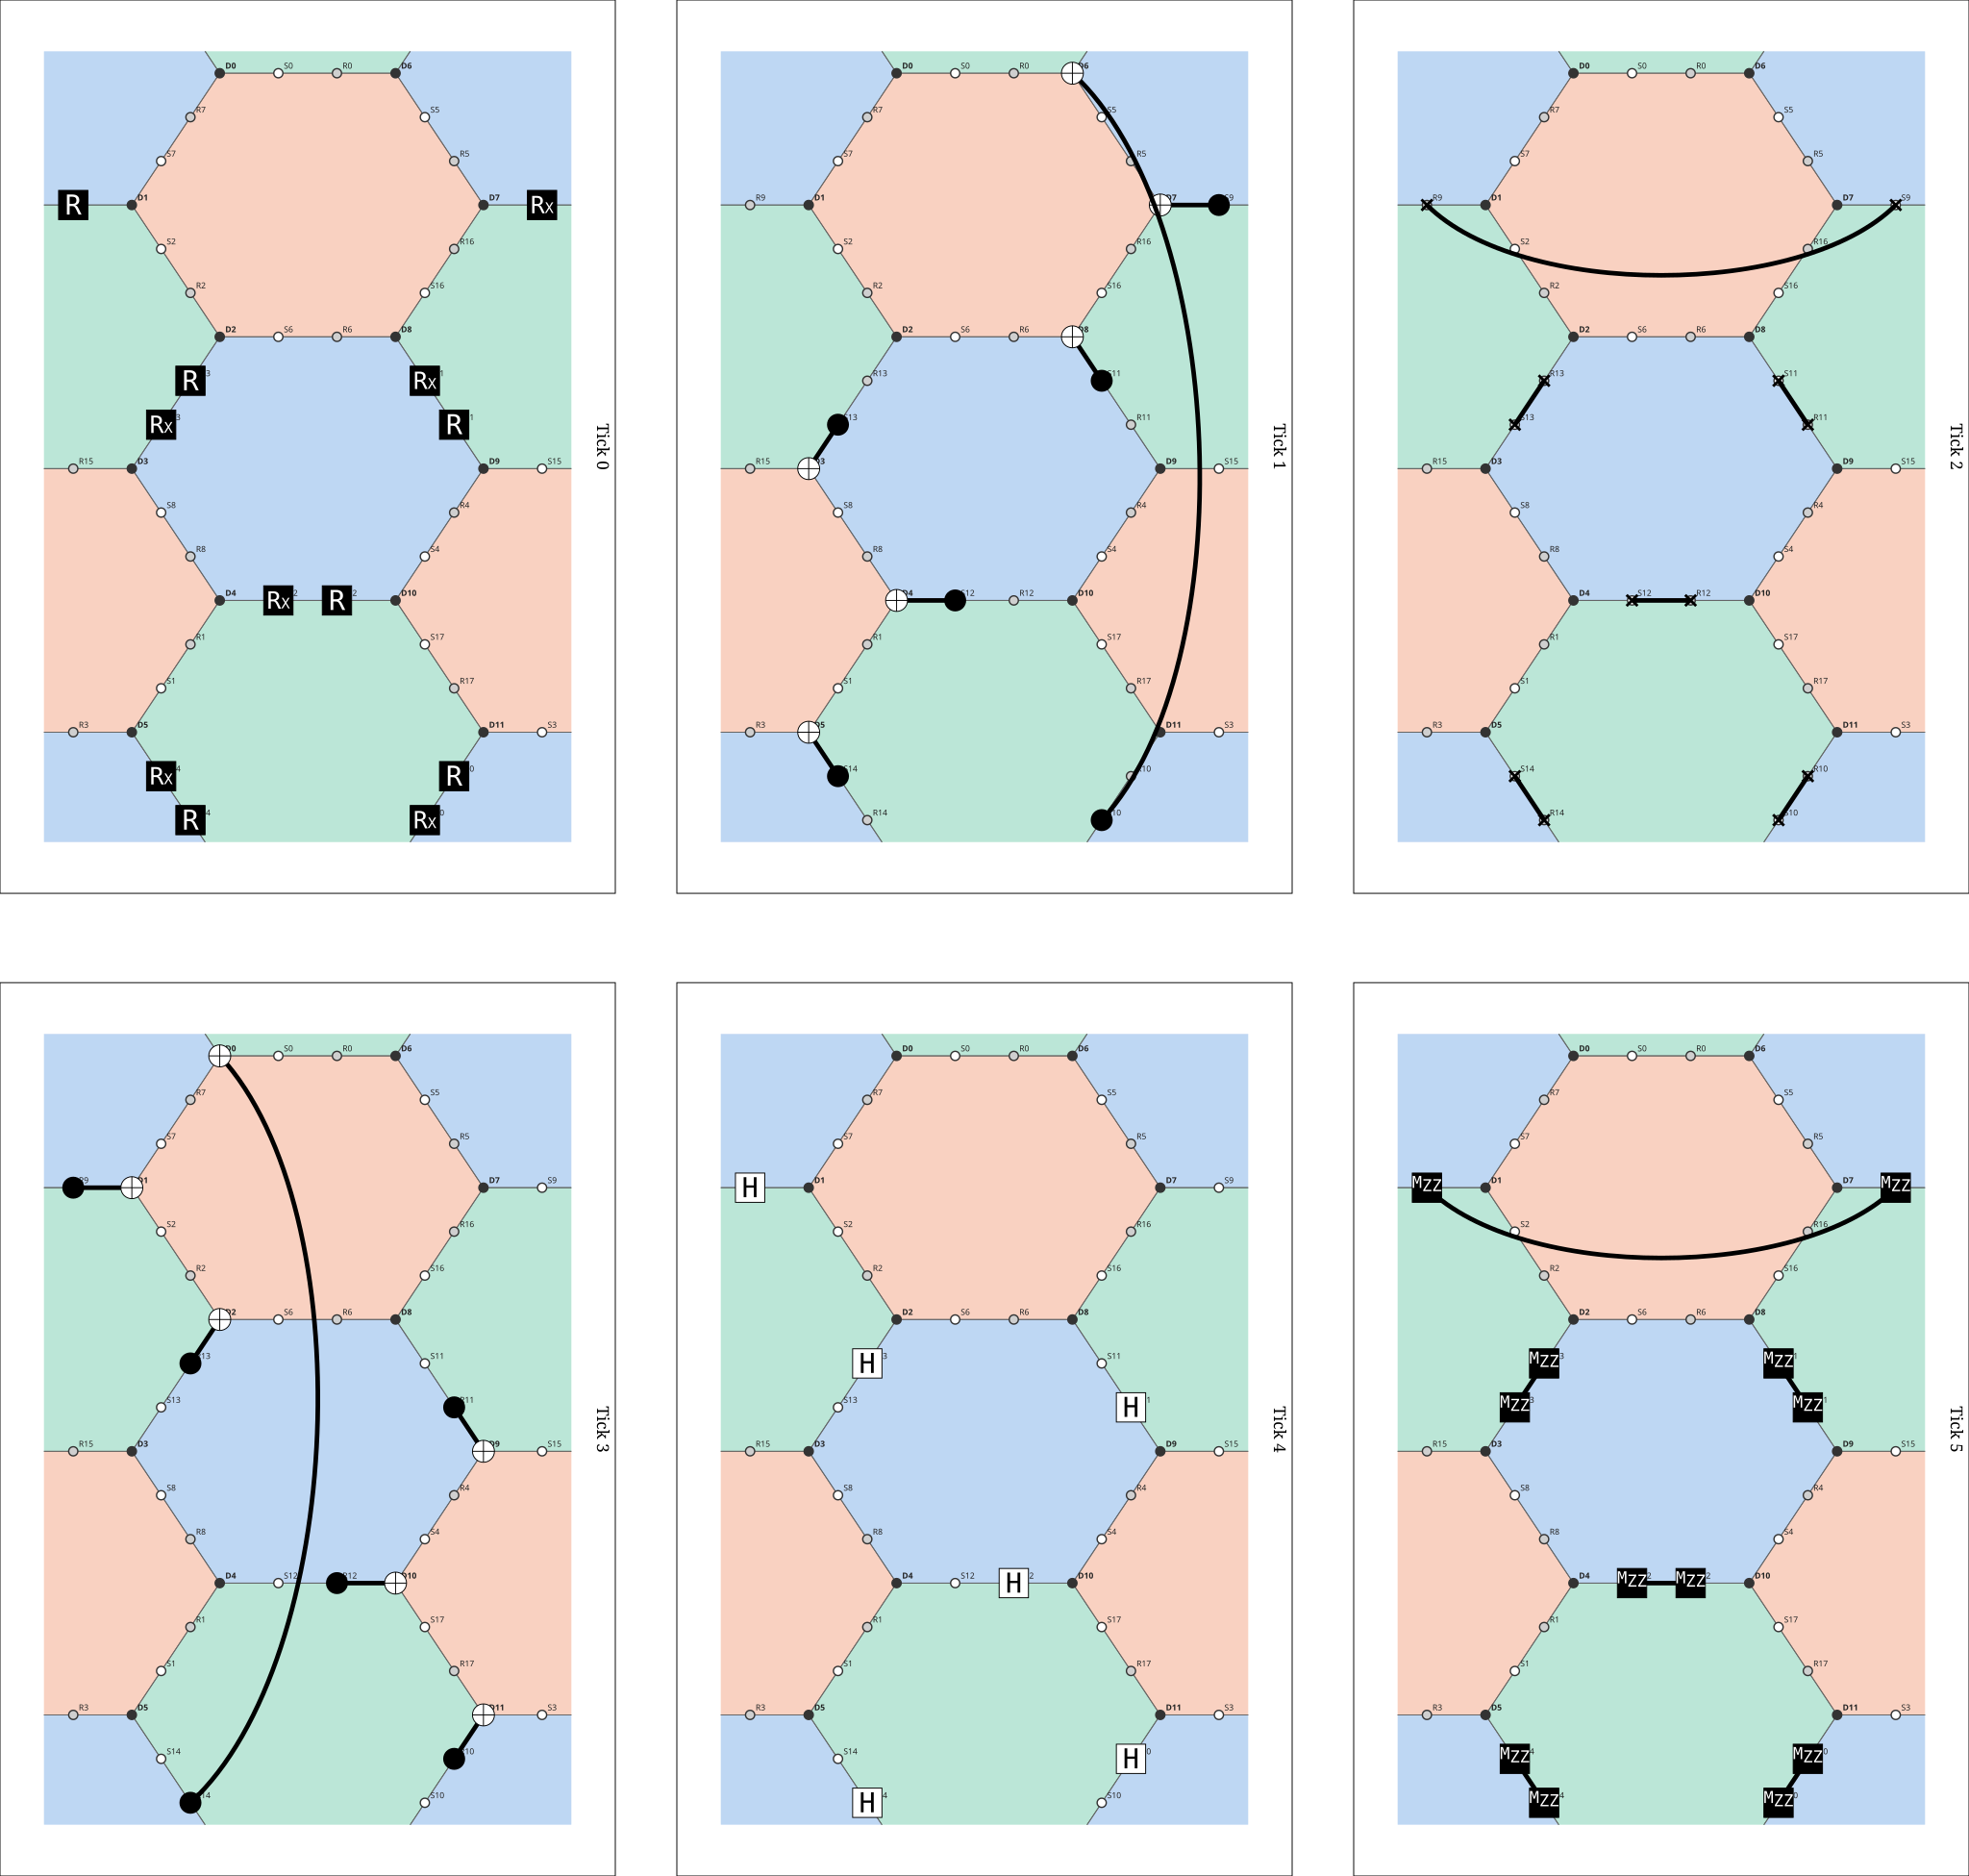

step 5: ZZ on colour 2 edges, 5 ticks


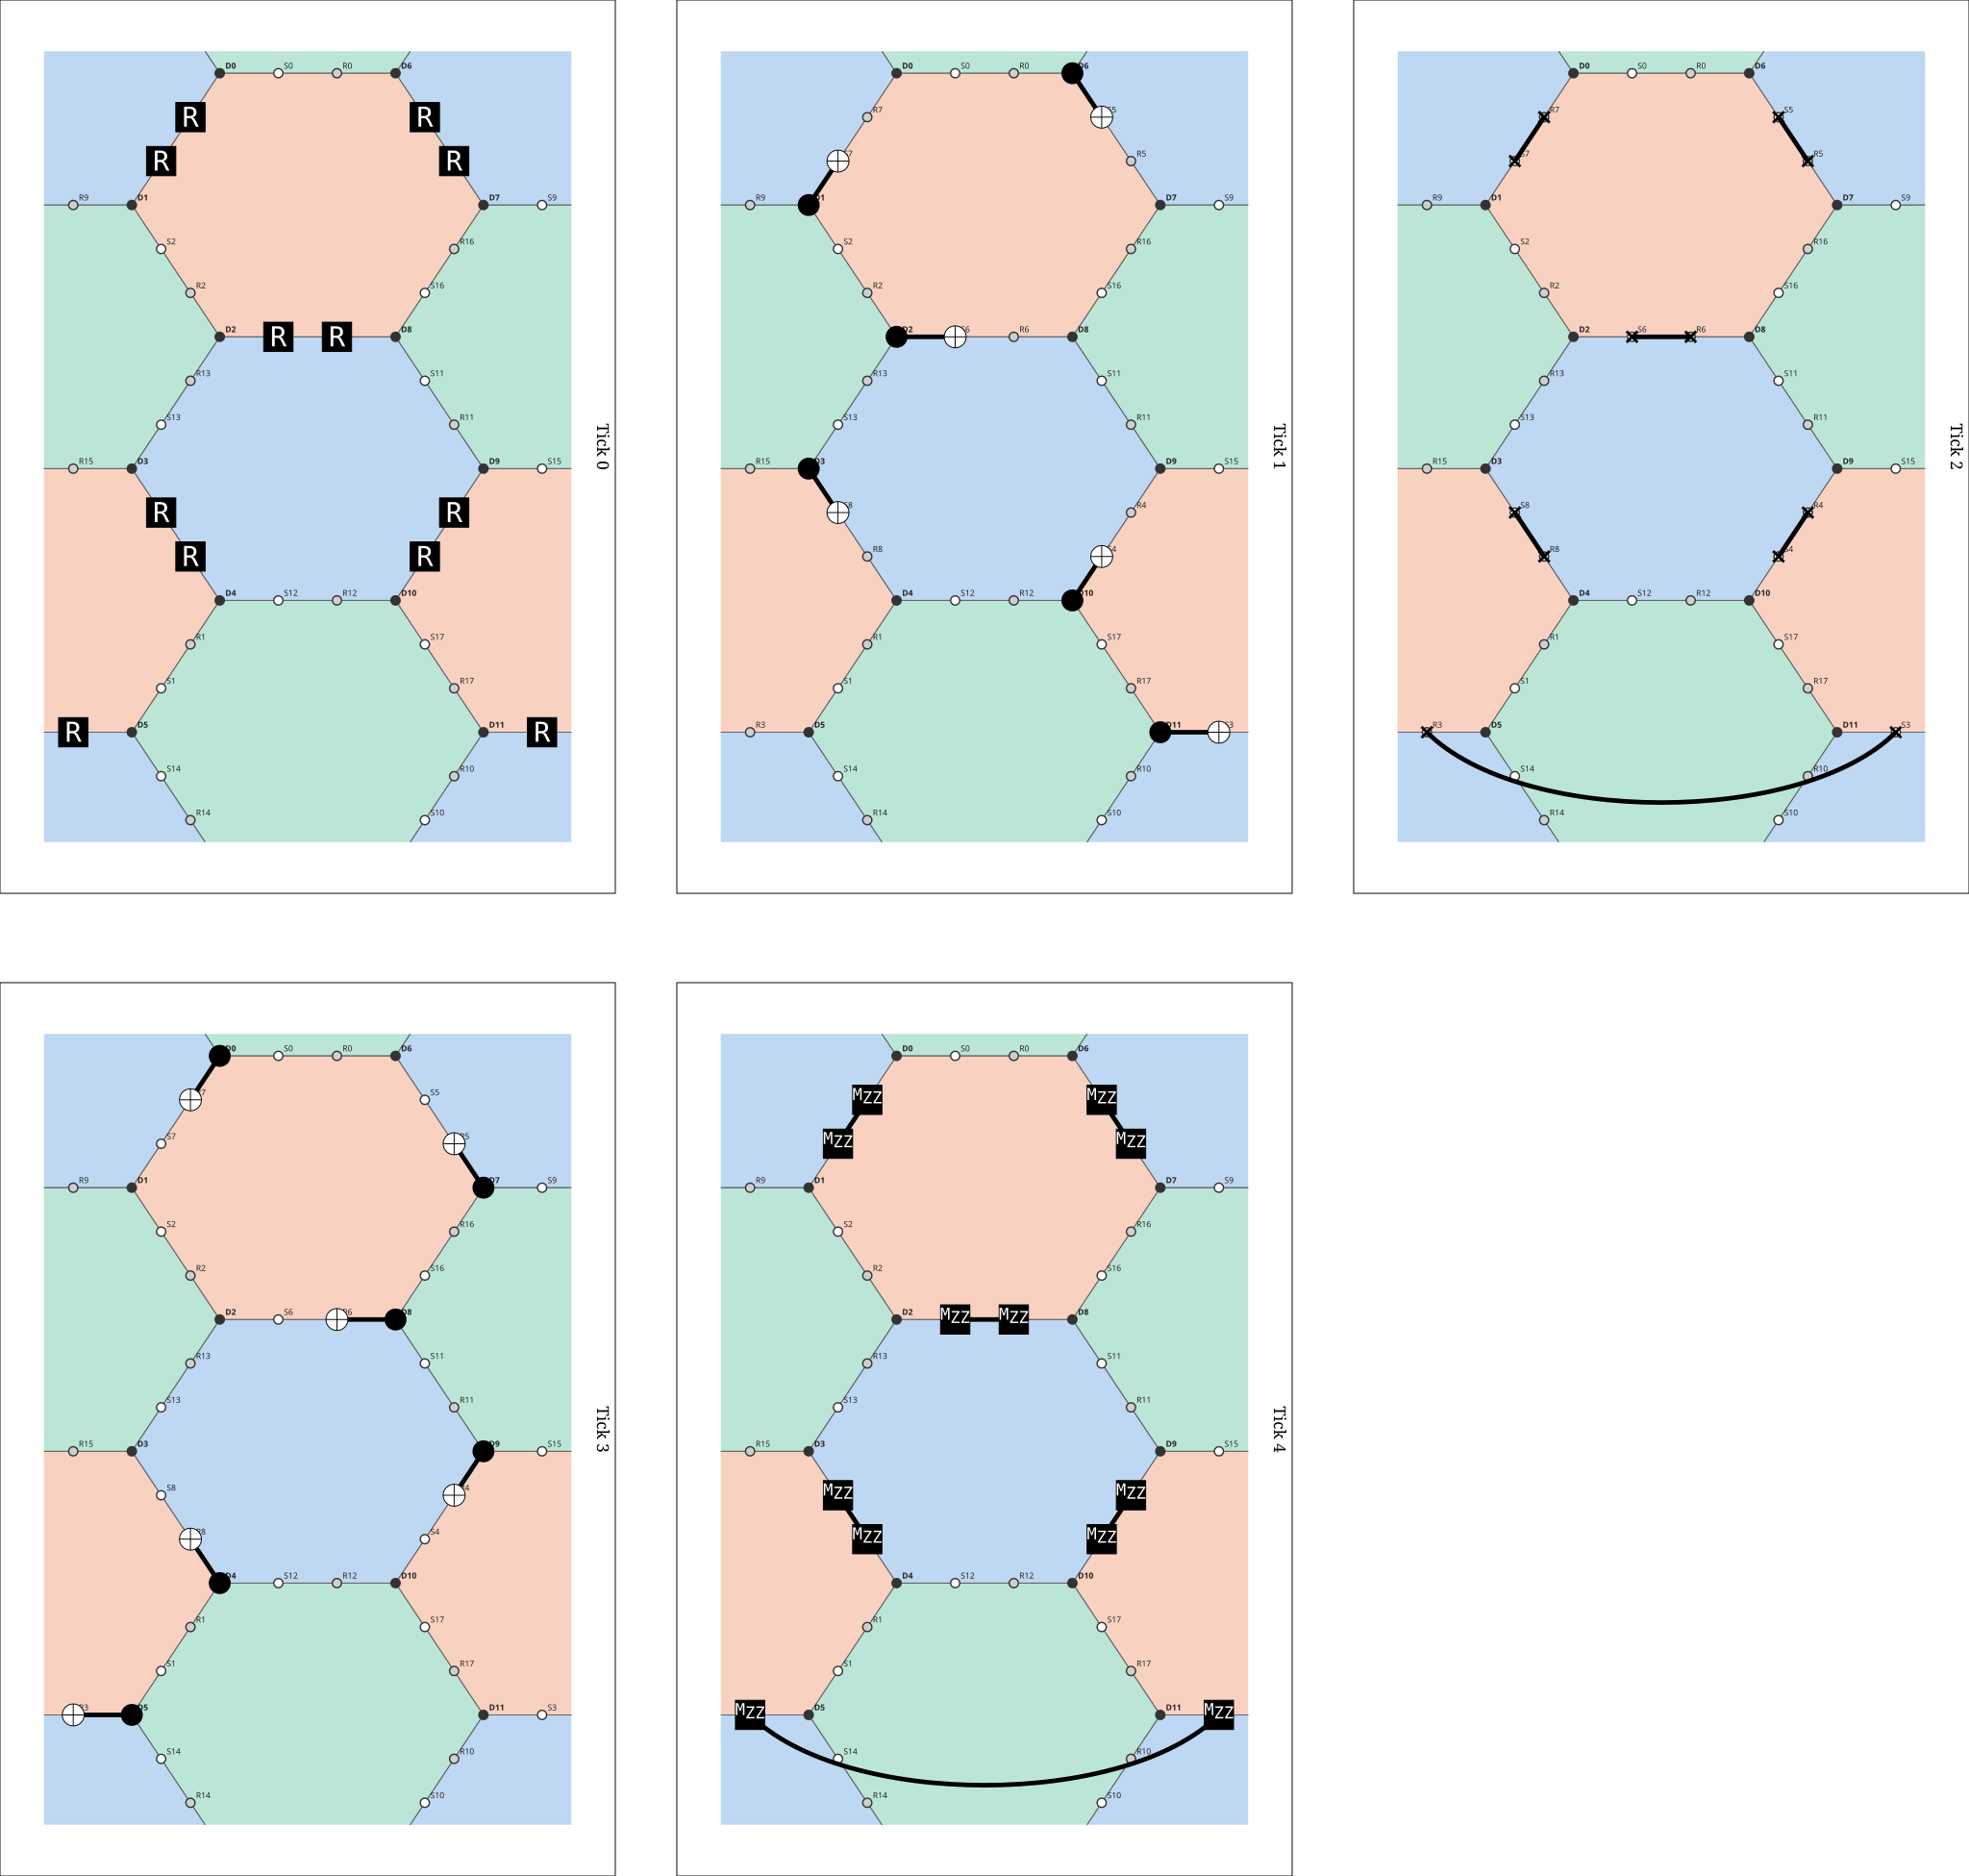

In [6]:
for r in range(6):
    step = round_circuit(DRAW, r)
    print(f"step {r}: {'XZ'[r % 2]}{'XZ'[r % 2]} on colour {r % 3} edges, {step.num_ticks} ticks")
    display(SVG(round_svg(DRAW, r, hex_view=True, numbers=True)))

## 5. What each step tells us: the detectors

A step of colour c, Pauli P:
* plaquettes of the **other two colours** have 3 of their 6 border edges checked → their P plaquette value is measured
  (product of those 3 outcomes). If it was known before, the new value is compared with the old: a **detector**.
* colour-c plaquettes are touched at single corners → their *other* Pauli is randomised.

The chart tracks every (Pauli, plaquette colour) value through two periods, starting after the Z reset.

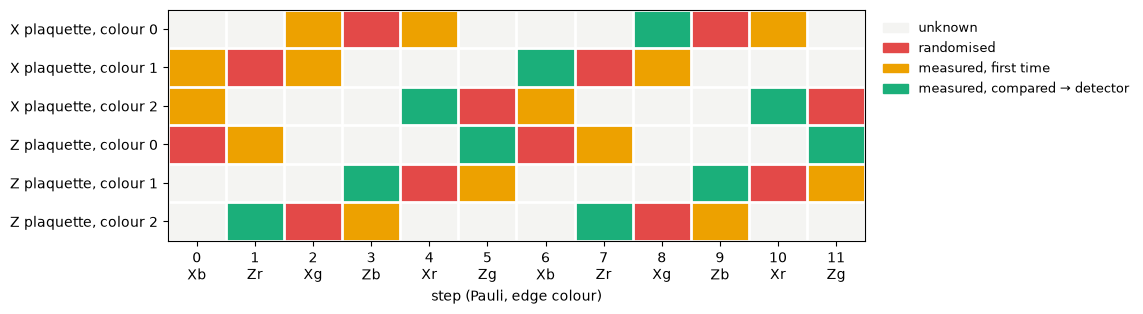

In [7]:
# 0 unknown, 1 randomised, 2 measured (first time), 3 measured and compared = detectors
known = {(p, c): p == "Z" for p in "XZ" for c in range(3)}
grid = np.zeros((6, 12), int)
for s in range(12):
    pauli, other, colour = "XZ"[s % 2], "ZX"[s % 2], s % 3
    for i, (p, c) in enumerate(known):
        if c == colour and p == other:
            known[(p, c)], grid[i, s] = False, 1
        elif c != colour and p == pauli:
            grid[i, s] = 3 if known[(p, c)] else 2
            known[(p, c)] = True

fig, ax = plt.subplots(figsize=(9, 3))
cmap = plt.matplotlib.colors.ListedColormap(["#f4f4f2", "#e34948", "#eda100", "#1baf7a"])
ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, aspect="auto")
ax.set_yticks(range(6), [f"{p} plaquette, colour {c}" for p, c in known])
ax.set_xticks(range(12), [f"{s}\n{'XZ'[s % 2]}{'brg'[s % 3]}" for s in range(12)])
ax.set_xlabel("step (Pauli, edge colour)")
ax.set_xticks(np.arange(-.5, 12), minor=True); ax.set_yticks(np.arange(-.5, 6), minor=True)
ax.grid(which="minor", color="white", lw=2); ax.tick_params(which="minor", length=0)
ax.legend(handles=[plt.matplotlib.patches.Patch(color=cmap(i), label=l) for i, l in
                   enumerate(["unknown", "randomised", "measured, first time", "measured, compared → detector"])],
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9);

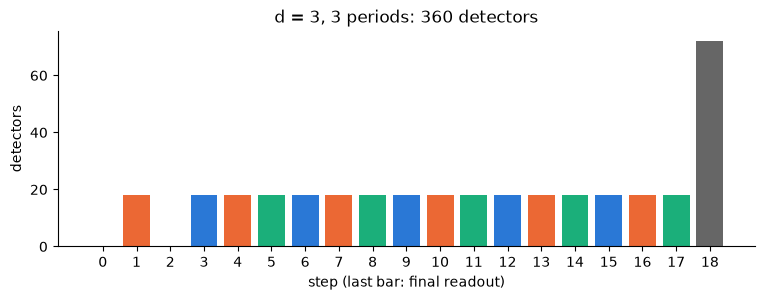

In [8]:
circuit = memory_circuit(D, D)

# Which step each detector belongs to: count measurement instructions (one MZZ per step, then the final M).
det_step, step = [], -1
for inst in circuit.flattened():
    if inst.name in ("MZZ", "M"):
        step += 1
    elif inst.name == "DETECTOR":
        det_step.append(step)
det_step = np.array(det_step)

counts = np.bincount(det_step)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(range(len(counts)), counts, color=[COLORS[s % 3] for s in range(len(counts) - 1)] + ["0.4"])
ax.set_xticks(range(len(counts)))
ax.set(xlabel="step (last bar: final readout)", ylabel="detectors",
       title=f"d = {D}, {D} periods: {circuit.num_detectors} detectors")
ax.spines[["top", "right"]].set_visible(False);

## 6. Observable and final readout

The logical Z runs along a horizontal loop in data rows y = 0, 1. No fixed operator survives every step,
so it is tracked as: every ZZ check with both qubits in rows 0–1, plus the final Z readout of row 0.
Final readout: every data qubit in Z; the last ZZ checks and the colour-2 Z plaquettes are compared with it.

In [9]:
data = qubits(D)
print("row 0 data qubits:", [q for q in data if q.imag == 0])
print(circuit[-3:])  # M, then the last detectors and OBSERVABLE_INCLUDE are just before

row 0 data qubits: [(1+0j), (3+0j), (5+0j), (7+0j), (9+0j), (11+0j)]
DETECTOR rec[-229] rec[-225] rec[-224] rec[-77] rec[-59] rec[-76] rec[-58] rec[-75] rec[-57]
DETECTOR rec[-226] rec[-222] rec[-221] rec[-41] rec[-23] rec[-40] rec[-22] rec[-39] rec[-21]
OBSERVABLE_INCLUDE(0) rec[-1026] rec[-1023] rec[-1020] rec[-918] rec[-915] rec[-912] rec[-808] rec[-805] rec[-802] rec[-800] rec[-797] rec[-794] rec[-702] rec[-699] rec[-696] rec[-594] rec[-591] rec[-588] rec[-484] rec[-481] rec[-478] rec[-476] rec[-473] rec[-470] rec[-378] rec[-375] rec[-372] rec[-270] rec[-267] rec[-264] rec[-160] rec[-157] rec[-154] rec[-152] rec[-149] rec[-146] rec[-108] rec[-90] rec[-72] rec[-54] rec[-36] rec[-18]


Without noise every detector must be 0 and the observable deterministic. `detector_error_model` would refuse a
circuit with a non-deterministic detector, so building it is the proof; sampling is the demo.

In [10]:
circuit.detector_error_model()
dets, obs = circuit.compile_detector_sampler().sample(1000, separate_observables=True)
print("any detector fired:", dets.any(), "| observable flipped:", obs.any())

any detector fired: False | observable flipped: False


## 7. Add noise

The `NOISE` model at physical error rate `P`. Detection events now appear; the heat map shows one shot,
the bars the fraction of shots each step's detectors fire on average.

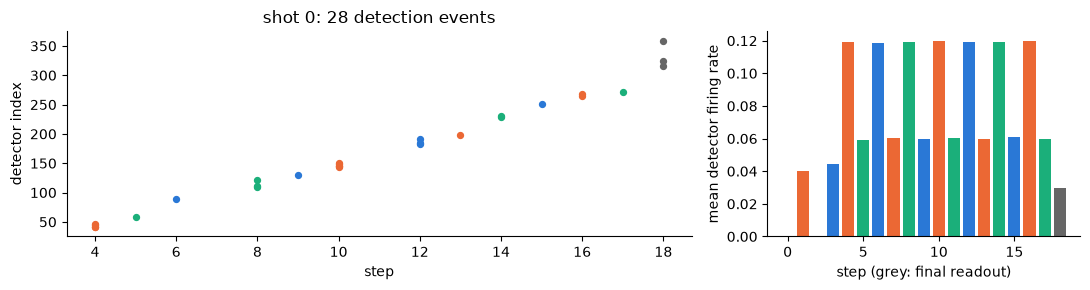

In [11]:
noisy = add_noise(circuit, NOISE_MODELS[NOISE](P, ETA))
dets, obs = noisy.compile_detector_sampler().sample(SHOTS, separate_observables=True)

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3), gridspec_kw={"width_ratios": [2, 1]})
shot = next(i for i in range(SHOTS) if dets[i].any())
for s in range(det_step.max() + 1):
    fired = np.flatnonzero(dets[shot] & (det_step == s))
    a.scatter(np.full(len(fired), s), fired, color=COLORS[s % 3] if s < det_step.max() else "0.4", s=18)
a.set(xlabel="step", ylabel="detector index", title=f"shot {shot}: {dets[shot].sum()} detection events")
rate = [dets[:, det_step == s].mean() if (det_step == s).any() else 0 for s in range(det_step.max() + 1)]
b.bar(range(len(rate)), rate, color=[COLORS[s % 3] for s in range(len(rate) - 1)] + ["0.4"])
b.set(xlabel="step (grey: final readout)", ylabel="mean detector firing rate")
for x in (a, b):
    x.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

In [12]:
err = noisy.shortest_graphlike_error()
print(f"circuit-level distance (shortest graphlike logical error): {len(err)} faults")

circuit-level distance (shortest graphlike logical error): 9 faults


## 8. Decode

Raw: how often the observable flips if we just read it. Decoded: MWPM (PyMatching) on the detection events.

raw 2.85e-01   decoded 0.00e+00


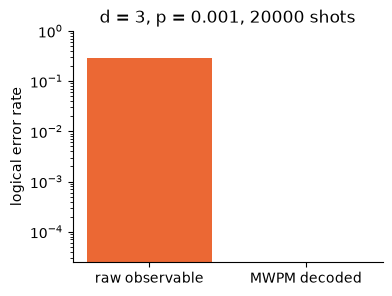

In [13]:
raw = obs[:, 0].mean()
decoded = count_logical_errors(noisy, SHOTS) / SHOTS
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["raw observable", "MWPM decoded"], [raw, decoded], color=[COLORS[1], COLORS[0]])
ax.set(ylabel="logical error rate", yscale="log", ylim=(0.5 / SHOTS, 1), title=f"d = {D}, p = {P:g}, {SHOTS} shots")
ax.spines[["top", "right"]].set_visible(False)
print(f"raw {raw:.2e}   decoded {decoded:.2e}")